In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk 
import webbrowser
import os

### step 1 : Load the data and some theroy

In [2]:
apps_df = pd.read_csv('googleplaystore.csv')
reviews_df = pd.read_csv('User_Reviews_Google_Play.csv')

In [3]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Telegram,Average experience overall.,Neutral,0.000000,0.211605
1,WhatsApp,Useful but has minor issues.,Neutral,0.000000,0.143469
2,Google Maps,NaN,NaN,NaN,NaN
3,Adobe Acrobat Reader,Excellent app with useful features.,Positive,0.648996,0.772816
4,WhatsApp,Love the interface and performance.,Positive,0.422553,0.895440


### step 2 : Data cleaning

In [5]:
apps_df = apps_df.dropna(subset=['Rating'])

In [6]:
for column in apps_df.columns:
    apps_df[column] = apps_df[column].fillna(apps_df[column].mode()[0])
apps_df.drop_duplicates(inplace=True)
apps_df = apps_df[apps_df['Rating']<=5]
reviews_df.dropna(subset=['Translated_Review'],inplace=True)

In [7]:
# # convert the installs columns to numeric by removing commas and +
# apps_df['Installs'] = apps_df['Installs'].str.replace(',', '').str.replace('+', '').astype(int)

# #convert Price columns to numeric after removing  $
# apps_df['Price'] = apps_df['Price'].str.replace('$', '').astype(float)


# Convert the Installs column to numeric by removing commas, plus signs, and stripping whitespace
apps_df['Installs'] = (
    apps_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    # .str.strip()
    .astype(int)
)

# Convert the Price column to numeric after removing $ signs and stripping whitespace
apps_df['Price'] = (
    apps_df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    # .str.strip()
    .astype(float) # astype() = "Data Type Change Karna"
)

In [8]:
apps_df.dtypes


App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [9]:
merged_df = pd.merge(apps_df,reviews_df, on="App",  how="inner")

In [10]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Telegram,COMMUNICATION,4.4,3128250,Varies with device,100000000,Free,0.0,Mature 17+,Communication,"July 27, 2018",Varies with device,Varies with device,Average experience overall.,Neutral,0.000000,0.211605
1,Telegram,COMMUNICATION,4.4,3128250,Varies with device,100000000,Free,0.0,Mature 17+,Communication,"July 27, 2018",Varies with device,Varies with device,"It's okay, needs some improvements.",Neutral,0.000000,0.301311
2,Telegram,COMMUNICATION,4.4,3128250,Varies with device,100000000,Free,0.0,Mature 17+,Communication,"July 27, 2018",Varies with device,Varies with device,Excellent app with useful features.,Positive,0.292273,0.976320
3,Telegram,COMMUNICATION,4.4,3128250,Varies with device,100000000,Free,0.0,Mature 17+,Communication,"July 27, 2018",Varies with device,Varies with device,Works great especially for daily use.,Positive,0.727081,0.427029
4,Telegram,COMMUNICATION,4.4,3128250,Varies with device,100000000,Free,0.0,Mature 17+,Communication,"July 27, 2018",Varies with device,Varies with device,Works great especially for daily use.,Positive,0.738237,0.379713


## Step 3 : Data Transformation

In [11]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan
apps_df['Size'] = apps_df['Size'].apply(convert_size)

In [12]:
apps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [13]:
pd.set_option('display.max_rows', None)

In [14]:
print(apps_df['Reviews'].dtype)

object


In [15]:
print(apps_df['Reviews'].unique()[:20])

['159' '967' '87510' '215644' '167' '178' '36815' '13791' '121' '13880'
 '8788' '44829' '4326' '1518' '55' '3632' '27' '194216' '224399' '450']


In [16]:
print(apps_df['Reviews'].head())

0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object


In [17]:
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

In [18]:
print(apps_df['Reviews'].dtype)

int64


In [19]:
apps_df['Log_Installs'] = np.log(apps_df['Installs'])
apps_df['Log_Reviews'] = np.log(apps_df['Reviews'])

In [20]:
def rating_group(rating):
    if rating >= 4:
        return 'Top rated app'
    elif rating >=3:
        return 'Above average'
    elif rating >=2:
        return 'Average'
    else:
        return 'Below average'
apps_df['Rating_Group']= apps_df['Rating'].apply(rating_group)        

In [21]:
# revenue column
apps_df['Revenue']=  apps_df['Price']*apps_df['Installs']

## Step 4 : Sentiment analysis NLP

In [22]:
sia = SentimentIntensityAnalyzer()

In [23]:
review = "This app is amazing ! I love the new features"
sentiment_score = sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.42, 'pos': 0.58, 'compound': 0.8516}


In [24]:
review = "This app is very bad! I hate the new features"
sentiment_score = sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.535, 'neu': 0.465, 'pos': 0.0, 'compound': -0.8427}


In [25]:
review = "This app is okay."
sentiment_score = sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.2263}


In [26]:
reviews_df['Sentiment_Score'] = reviews_df['Translated_Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

In [27]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Score
0,Telegram,Average experience overall.,Neutral,0.000000,0.211605,0.0000
1,WhatsApp,Useful but has minor issues.,Neutral,0.000000,0.143469,0.2382
3,Adobe Acrobat Reader,Excellent app with useful features.,Positive,0.648996,0.772816,0.7650
4,WhatsApp,Love the interface and performance.,Positive,0.422553,0.895440,0.6369
5,YouTube,Works fine but can be better.,Neutral,0.000000,0.238936,0.6428


In [28]:
apps_df['Last Updated'] = pd.to_datetime(
    apps_df['Last Updated'],
    errors='coerce'
)

In [29]:
apps_df['Year'] = apps_df['Last Updated'].dt.year

In [30]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Log_Installs,Log_Reviews,Rating_Group,Revenue,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,9.210340,5.068904,Top rated app,0.0,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,13.122363,6.874198,Above average,0.0,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,15.424948,11.379508,Top rated app,0.0,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,17.727534,12.281384,Top rated app,0.0,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,11.512925,6.874198,Top rated app,0.0,2018


## Step 5 : Plotly

In [31]:
plot_containers = ""

In [32]:
def save_plot_as_html(fig, filename, description):
    fig.write_html(filename)
    print(f"Saved: {filename}")
    print(description)

In [33]:
# save each plotly  figure to an HTML file
def save_plot_as_html(fig,filename,insight):
    global plot_containers
    filepath = os.path.join(html_file_path, filename)
    html_content = pio.to_html(fig,full_html=False, include_plotlyjs="inline")
    #append the plot and its insight to plot_containers
    plot_containers += f"""
    <div class="plot-container" = id = "{filename}" onclick= "openPlot('{filename}')">
        <div class =  "plot">{html_content}</div>
        <div class =  "insight">{insight}</div>
    </div> """

    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

In [34]:
plot_width= 500
plot_height = 400
plot_bg_color = 'white'
title_font = {'size' : 16}
axis_font = {'size' : 12}

In [35]:
## correction code by chatgpt
import os
import plotly.io as pio
import plotly.express as px

# Create folder to store HTML files
html_file_path = "plots"
os.makedirs(html_file_path, exist_ok=True)

# Container to store plots for dashboard
plot_containers = ""

# Function to save Plotly figures
def save_plot_as_html(fig, filename, insight):
    global plot_containers

    # Full file path
    filepath = os.path.join(html_file_path, filename)

    # Convert figure to HTML
    html_content = pio.to_html(
        fig,
        full_html=False,
        include_plotlyjs="inline"
    )

    # Store plot HTML and insight
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
        <div class="plot">
            {html_content}
        </div>
        <div class="insight">
            <p>{insight}</p>
        </div>
    </div>
    """

    # Save HTML file
    fig.write_html(
        filepath,
        full_html=False,
        include_plotlyjs="inline"
    )

    print(f"Saved: {filepath}")


# ------------------ Graph Settings ------------------

plot_width = 600
plot_height = 500
plot_bg_color = "black"

title_font = {"size": 16}
axis_font = {"size": 12}


# ------------------ Figure 1 ------------------

category_count = apps_df["Category"].value_counts().nlargest(10)

fig1 = px.bar(
    x=category_count.index,
    y=category_count.values,
    labels={"x": "Category", "y": "Count"},
    title="Top Categories on Play Store",
    color=category_count.index,
    color_discrete_sequence=px.colors.sequential.Plasma,
    width=500,
    height=400
)

fig1.update_layout(
    plot_bgcolor="black",
    paper_bgcolor="black",
    font_color="white",
    title_font=title_font,
    xaxis_title="Category",
    yaxis_title="Count",
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=30, t=40, b=10)
)

fig1.update_traces(
    marker=dict(
        line=dict(color="white", width=1)
    )
)
# Show plot
fig1.show()


# Save the graph
save_plot_as_html(
    fig1,
    "Category_Graph_1.html",
    "The top categories on the Play Store are dominated by Tools, Entertainment, and Productivity apps."
)

Saved: plots\Category_Graph_1.html


In [36]:
# Figure 2 - Pie Chart

type_count = apps_df['Type'].value_counts()

fig2 = px.pie(
    values=type_count.values,
    names=type_count.index,
    title="App Type Distribution",
    color=type_count.index,
    color_discrete_sequence=px.colors.sequential.RdBu,
    width=500,
    height=400
)

fig2.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker=dict(
        line=dict(color='white', width=2)
    )
)

fig2.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font=dict(size=18),
    legend_title="App Type",
    margin=dict(l=10, r=30, t=50, b=10)
)
# Show plot
fig2.show()

save_plot_as_html(
    fig2,
    "Type_Graph_2.html",
    "Most applications on the Play Store are free, accounting for the vast majority of apps, while paid apps make up only a small percentage."
)

Saved: plots\Type_Graph_2.html


In [37]:
# ------------------ Figure 3 ------------------

fig3 = px.histogram(
    apps_df,
    x="Rating",
    nbins=20,
    title="Rating Distribution",
    color_discrete_sequence=["#636EFA"],
    width=500,
    height=400
)

fig3.update_traces(
    marker=dict(
        line=dict(color="white", width=1)
    ),
    opacity=0.85
)

fig3.update_layout(
    plot_bgcolor="black",
    paper_bgcolor="black",
    font_color="white",
    title_font=dict(size=18),
    xaxis_title="Rating",
    yaxis_title="Number of Apps",
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=30, t=50, b=10)
)
# Show plot
fig3.show()

save_plot_as_html(
    fig3,
    "Rating_Graph_3.html",
    "Ratings are skewed toward higher values, suggesting that most apps are rated favorably by users."
)

Saved: plots\Rating_Graph_3.html


In [38]:
# ------------------ Figure 4 ------------------

sentiment_counts = reviews_df['Sentiment_Score'].value_counts()

fig4 = px.bar(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    title="Sentiment Distribution",
    labels={"x": "Sentiment Score", "y": "Count"},
    color=sentiment_counts.index,
    width=500,
    height=400
)

fig4.update_layout(
    plot_bgcolor="black",
    paper_bgcolor="black",
    font_color="white",
    title_font=dict(size=20, color="white"),
    xaxis=dict(title_font=dict(size=14, color="white")),
    yaxis=dict(title_font=dict(size=14, color="white")),
    margin=dict(l=10, r=10, t=30, b=10)
)

fig4.update_traces(
    marker=dict(line=dict(color="white", width=1))
)

# Show plot
fig4.show()

# Save plot as HTML
save_plot_as_html(
    fig4,
    "Sentiment Distribution 4.html",
    "Distribution of sentiment scores across app reviews."
)

Saved: plots\Sentiment Distribution 4.html


In [39]:
# ------------------ Figure 5 ------------------

installs_by_category = apps_df.groupby('Category')['Installs'].sum().nlargest(10)

fig5 = px.bar(
    x=installs_by_category.index,
    y=installs_by_category.values,
    orientation='h',
    labels={"x": "Installs", "y": "Category"},
    title="Installs by Category",
    color=installs_by_category.index,
    color_discrete_sequence=px.colors.sequential.Blues,
    width=500,
    height=400
)

fig5.update_layout(
    plot_bgcolor="black",
    paper_bgcolor="black",
    font_color="white",
    title_font=dict(size=20, color="white"),
    xaxis=dict(title_font=dict(size=14, color="white")),
    yaxis=dict(title_font=dict(size=14, color="white")),
    margin=dict(l=10, r=10, t=30, b=10)
)

fig5.update_traces(
    marker=dict(line=dict(color="white", width=1))
)

# Show plot
fig5.show()

# Save plot as HTML
save_plot_as_html(
    fig5,
    "Installs by Category 5.html",
    "Top 10 app categories based on total installs."
)

Saved: plots\Installs by Category 5.html


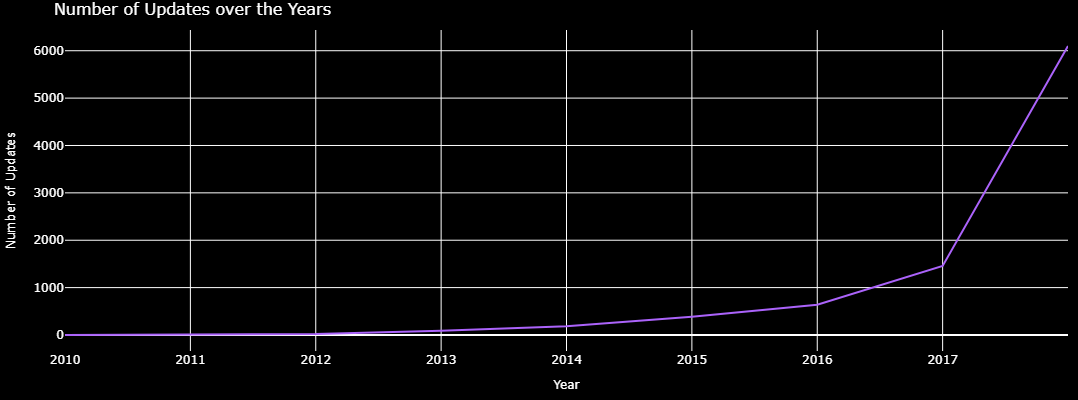

Saved: plots\Updates Graph 6.html


In [40]:
# ------------------ Figure 6 ------------------

updates_per_year = apps_df['Last Updated'].dt.year.value_counts().sort_index()

fig6 = px.line(
    x=updates_per_year.index,
    y=updates_per_year.values,
    labels={'x': 'Year', 'y': 'Number of Updates'},
    title='Number of Updates over the Years',
    color_discrete_sequence=['#AB63FA'],
    width=500,
    height=400
)

fig6.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)
# Show plot
fig6.show()

# Save HTML
save_plot_as_html(
    fig6,
    "Updates Graph 6.html",
    "Updates have been analyzed year-wise."
)

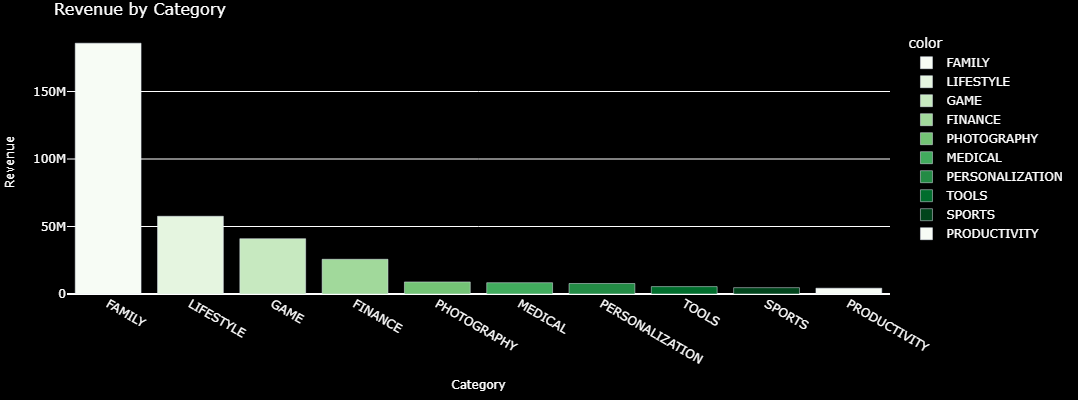

Saved: plots\Revenue Graph 7.html


In [41]:
# ------------------ Figure 7 ------------------

revenue_by_category = apps_df.groupby('Category')['Revenue'].sum().nlargest(10)

fig7 = px.bar(
    x=revenue_by_category.index,
    y=revenue_by_category.values,
    labels={'x': 'Category', 'y': 'Revenue'},
    title='Revenue by Category',
    color=revenue_by_category.index,
    color_discrete_sequence=px.colors.sequential.Greens,
    width=500,
    height=400
)

fig7.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)

# Show plot
fig7.show()

# Save plot as HTML
save_plot_as_html(
    fig7,
    "Revenue Graph 7.html",
    "Categories such as Business and Productivity lead in revenue generation, indicating their monetization potential."
)

In [42]:
# ------------------ Figure 8 ------------------

genre_counts = (
    apps_df['Genres'].str.split(';', expand=True).stack().value_counts().nlargest(10)
)

fig8 = px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    labels={'x': 'Genre', 'y': 'Count'},
    title='Top Genres',
    color=genre_counts.index,
    color_discrete_sequence=px.colors.sequential.OrRd,
    width=500,
    height=400
)

fig8.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)

# Show plot
fig8.show()

# Save plot as HTML
save_plot_as_html(
    fig8,
    "Genre Graph 8.html",
    "Action and Casual genres are the most common, reflecting users' preference for engaging and easy-to-play games."
)

Saved: plots\Genre Graph 8.html


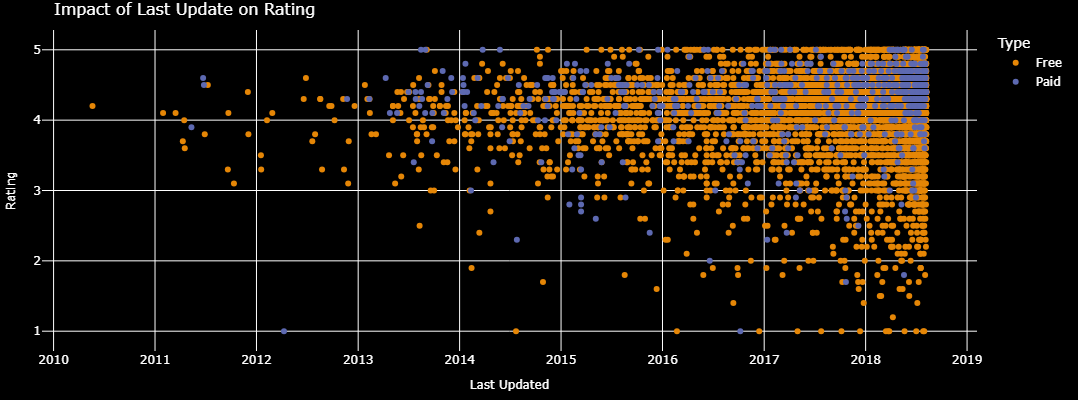

Saved: plots\Update Graph 9.html


In [43]:
# ------------------ Figure 9 ------------------

fig9 = px.scatter(
    apps_df,
    x='Last Updated',
    y='Rating',
    color='Type',
    title='Impact of Last Update on Rating',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    render_mode='svg',
    width=500,
    height=400
)

fig9.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)

# Show plot
fig9.show()

# Save plot as HTML
save_plot_as_html(
    fig9,
    "Update Graph 9.html",
    "The scatter plot shows the relationship between the last update date and app ratings."
)

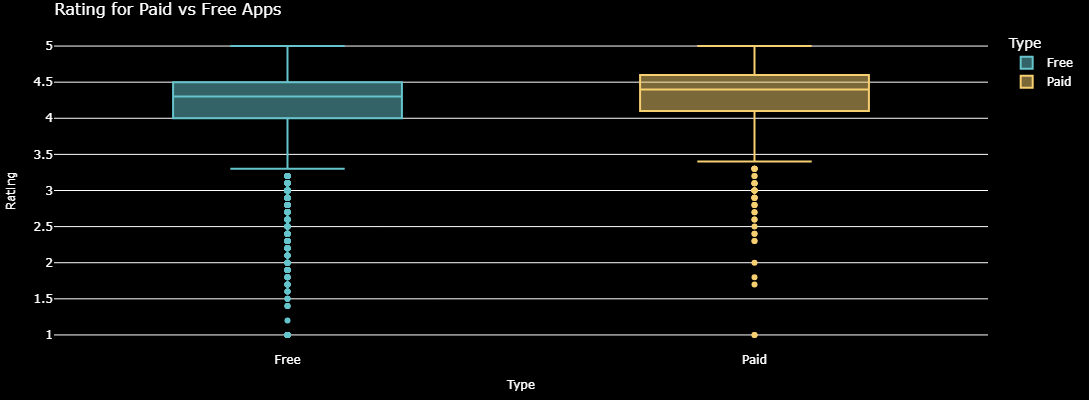

Saved: plots\Paid Free Graph 10.html


In [44]:
# ------------------ Figure 10 ------------------

fig10 = px.box(
    apps_df,
    x='Type',
    y='Rating',
    color='Type',
    title='Rating for Paid vs Free Apps',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    width=500,
    height=400
)

fig10.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)

# Show plot
fig10.show()

# Save plot as HTML
save_plot_as_html(
    fig10,
    "Paid Free Graph 10.html",
    "Paid apps generally have higher ratings compared to free apps, suggesting that users may expect higher quality from paid applications."
)

In [45]:
plot_containers_split= plot_containers.split('</div>')

In [46]:
if len(plot_containers_split)>1:
    final_plot = plot_containers_split[-2]+'</div>'
else:
    final_plot = plot_containers

## Step 6 : Creating web Dashboard

In [47]:
dashboard_html = """
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Google Play Store Review Analytics</title>

    <style>

        body {
            font-family: Arial, sans-serif;
            background-color: #333;
            color: #fff;
            margin: 0;
            padding: 0;
        }

        .header {
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 20px;
            background-color: #444;
        }

        .header img {
            margin: 0 10px;
            height: 50px;
        }

        .container {
            display: flex;
            flex-wrap: wrap;
            justify-content: center;
            padding: 20px;
        }

        .plot-container {
            border: 2px solid #555;
            margin: 10px;
            padding: 10px;
            height: PLOT_HEIGHTpx;
            width: PLOT_WIDTHpx;
            overflow: hidden;
            position: relative;
            cursor: pointer;
        }

        .insights {
            display: none;
            position: absolute;
            right: 10px;
            top: 10px;
            background-color: rgba(0, 0, 0, 0.7);
            padding: 5px;
            border-radius: 5px;
            color: #fff;
        }

        .plot-container:hover .insights {
            display: block;
        }

    </style>

</head>

<body>

    <div class="header">

        <img
            width="48"
            height="48"
            src="https://img.icons8.com/color/48/google-logo.png"
            alt="Google Logo"
        >

        <h1>Google Play Store Review Analytics</h1>

        <img
            width="48"
            height="48"
            src="https://img.icons8.com/fluency/48/google-play-store-new.png"
            alt="Google Play Store"
        >

    </div>

    <div class="container">

        PLOTS_HERE

    </div>

</body>

</html>
"""

In [52]:
plot_width = 500
plot_height = 400

# Create HTML folder
html_files_path = "html_files"
os.makedirs(html_files_path, exist_ok=True)

# Replace placeholders
final_html = dashboard_html.replace(
    "PLOTS_HERE",
    plot_containers
)

final_html = final_html.replace(
    "PLOT_WIDTH",
    str(plot_width)
)

final_html = final_html.replace(
    "PLOT_HEIGHT",
    str(plot_height)
)

# Dashboard path
dashboard_path = os.path.join(
    html_files_path,
    "web page.html"
)

# Save
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(final_html)

print("Dashboard saved successfully!")
print("Location:", os.path.abspath(dashboard_path))

# Open in browser
webbrowser.open(
    "file://" + os.path.realpath(dashboard_path)
)

Dashboard saved successfully!
Location: C:\Users\piyus\OneDrive\Desktop\Elevanceskills-internship\playstore data analysis\html_files\web page.html


True